In [13]:
#--Intilize the chat model using the GROQ API key from the environment variables
import os 
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
# print("GROQ_API_KEY is set to:", os.getenv("GROQ_API_KEY"))
model = init_chat_model("groq:llama-3.1-8b-instant")
response = model.invoke("What is captial of India?")
print(response.content)

The capital of India is New Delhi.


In [ ]:
# Step 1 ---Import the necessary modules and classes from langgraph and typing_extensions---
from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
from typing import TypedDict
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_tavily import TavilySearch

# Step 2 ------------------ State definition for the graph------
class State(TypedDict):
    messages:Annotated[list, add_messages]

# Step 3 -----------------Define the Node function for the graph----------------
def tool_calling_node(state:State):
    return {"messages":[model.invoke(state["messages"])]}

# Step 4 --- Define the tools that will be used in the graph -----
Search_tool = TavilySearch(
    max_results=2,
    topice="general"
)
tools = [Search_tool]
# Step 5 ---------------- Define the graph and add the nodes to it----------------
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_node",tool_calling_node)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_edge(START, "tool_calling_node")
graph_builder.add_conditional_edges("tool_calling_node", 
# If there is two nodes , we use add_conditional_edges to route the flow based on the condition
 #If the Lastest message(result) from assistant is a tool call -> tools_condation routes to tools                           
   tools_condition
)
graph_builder.add_edge("tools", END)

# Step 6 ----------------- Execute the graph----------------
graph = graph_builder.compile()
print(graph)

#Step 7 ----------------- Test the graph with a query that requires tool usage----------------
User_query = "What is the captial of India and also search about it?"
response = graph.invoke({
    "messages":[{"role":"user","content":User_query}]
})

response

{'messages': [HumanMessage(content='What is the captial of India and also search about it?', additional_kwargs={}, response_metadata={}, id='8e19422e-bf4c-4fe3-aa6f-402b886b61c6'),
  AIMessage(content="The capital of India is **New Delhi**.\n\n**About New Delhi:**\n\nNew Delhi is the capital and the second-most populous city of India, after Mumbai. Located in the northern part of the country, it is a major hub for politics, culture, and economy. Here are some interesting facts about New Delhi:\n\n**History:** New Delhi was founded in 1911 by the British colonial government, who decided to shift the capital from Calcutta (now Kolkata) to Delhi. The city was designed by British architects Edwin Lutyens and Herbert Baker, and it was officially inaugurated in 1931.\n\n**Architecture:** New Delhi is known for its stunning architecture, which reflects a mix of Indian, Mughal, and British styles. The city is home to many iconic landmarks, including the India Gate, the Qutub Minar, and the Red

In [16]:
response["messages"][-1].content

"The capital of India is **New Delhi**.\n\n**About New Delhi:**\n\nNew Delhi is the capital and the second-most populous city of India, after Mumbai. Located in the northern part of the country, it is a major hub for politics, culture, and economy. Here are some interesting facts about New Delhi:\n\n**History:** New Delhi was founded in 1911 by the British colonial government, who decided to shift the capital from Calcutta (now Kolkata) to Delhi. The city was designed by British architects Edwin Lutyens and Herbert Baker, and it was officially inaugurated in 1931.\n\n**Architecture:** New Delhi is known for its stunning architecture, which reflects a mix of Indian, Mughal, and British styles. The city is home to many iconic landmarks, including the India Gate, the Qutub Minar, and the Red Fort.\n\n**Cultural significance:** New Delhi is a melting pot of cultures, with people from all over India and the world living and working there. The city is famous for its street food, markets, and

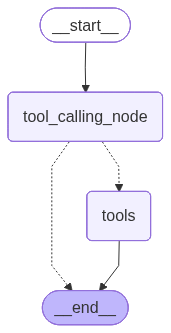

In [17]:
from IPython.display import Image , display
try:    
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Error visualizing the graph: ", e)